In [1]:
import numpy as np
import bacco

import matplotlib.pyplot as plt
bacco.plotting.set_defaults(useTex=False)
import halotools.mock_observables as ht

In [3]:
%load_ext autoreload
%autoreload 2

In [2]:
# base = "/cosmos_storage/simulations/MTNG/lite_snap_214"

# sigma8 = 0.8159 #CHECK ME
# ns     = 0.9667 #CHECK ME
# tau    = 0.0965 #CHECK ME

# mtng_snap = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(_snap,_snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(_snap,_snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
#                         tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(_snap,_snap), numpart=4320**3)


NameError: name '_snap' is not defined

In [4]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

_snap = 214
zoom_snap = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(_snap,_snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(_snap,_snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(_snap,_snap), numpart=4320**3)


print(zoom_snap.header['Redshift'])

2026-03-12 15:48:30,268 bacco.sims : Initialising simulation Default
2026-03-12 15:48:30,270 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_214/snapshot_214
2026-03-12 15:48:30,272 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_214/snapshot_214
2026-03-12 15:48:30,664 bacco.sims : ...done in 0.00933 s


0.5010140696264258


# Load particles

In [5]:
pos_gas = zoom_snap.gas['pos']
mass_gas = zoom_snap.gas['mass']
vel_gas = zoom_snap.gas['vel'].T[2]

mom_gas = mass_gas * vel_gas

2026-03-12 15:48:33,414 bacco.sims : Read data for 14534871/116263756 particles...


/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_214/snapshot_214.0.hdf5


2026-03-12 15:48:34,902 bacco.sims : Read data for 14534871/116263756 particles...
2026-03-12 15:48:34,918 bacco.sims : Read data for 14557995/116263756 particles...
2026-03-12 15:48:36,395 bacco.sims : Read data for 14557995/116263756 particles...
2026-03-12 15:48:36,416 bacco.sims : Read data for 14513391/116263756 particles...
2026-03-12 15:48:37,909 bacco.sims : Read data for 14513391/116263756 particles...
2026-03-12 15:48:37,926 bacco.sims : Read data for 14545167/116263756 particles...
2026-03-12 15:48:39,395 bacco.sims : Read data for 14545167/116263756 particles...
2026-03-12 15:48:39,416 bacco.sims : Read data for 14514841/116263756 particles...
2026-03-12 15:48:40,970 bacco.sims : Read data for 14514841/116263756 particles...
2026-03-12 15:48:40,990 bacco.sims : Read data for 14567529/116263756 particles...
2026-03-12 15:48:42,471 bacco.sims : Read data for 14567529/116263756 particles...
2026-03-12 15:48:42,499 bacco.sims : Read data for 14516180/116263756 particles...
2026

In [6]:
pos_hr = zoom_snap.dm['pos']
vel_hr = zoom_snap.dm['vel'].T[2]
mass_hr = np.ones_like(vel_hr)  * zoom_snap.header['ParticleMass']
mom_hr = mass_hr*vel_hr

2026-03-12 15:48:46,668 bacco.sims : Read data for 11501391/91882808 particles...


/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_214/snapshot_214.0.hdf5


2026-03-12 15:48:47,585 bacco.sims : Read data for 11501391/91882808 particles...
2026-03-12 15:48:47,587 bacco.sims : Read data for 11387827/91882808 particles...
2026-03-12 15:48:48,494 bacco.sims : Read data for 11387827/91882808 particles...
2026-03-12 15:48:48,497 bacco.sims : Read data for 11381444/91882808 particles...
2026-03-12 15:48:49,403 bacco.sims : Read data for 11381444/91882808 particles...
2026-03-12 15:48:49,405 bacco.sims : Read data for 11500628/91882808 particles...
2026-03-12 15:48:50,311 bacco.sims : Read data for 11500628/91882808 particles...
2026-03-12 15:48:50,316 bacco.sims : Read data for 11524188/91882808 particles...
2026-03-12 15:48:51,207 bacco.sims : Read data for 11524188/91882808 particles...
2026-03-12 15:48:51,211 bacco.sims : Read data for 11545276/91882808 particles...
2026-03-12 15:48:52,095 bacco.sims : Read data for 11545276/91882808 particles...
2026-03-12 15:48:52,098 bacco.sims : Read data for 11494226/91882808 particles...
2026-03-12 15:48

In [7]:
pos_lr = zoom_snap.lowres_dm['pos']
vel_lr = zoom_snap.lowres_dm['vel'].T[2]
mass_lr = zoom_snap.lowres_dm['mass']
mom_lr = mass_lr*vel_lr

2026-03-12 15:48:54,876 bacco.sims : Read data for 2286260/18161322 particles...


/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_214/snapshot_214.0.hdf5


2026-03-12 15:48:55,059 bacco.sims : Read data for 2286260/18161322 particles...
2026-03-12 15:48:55,061 bacco.sims : Read data for 2331221/18161322 particles...
2026-03-12 15:48:55,242 bacco.sims : Read data for 2331221/18161322 particles...
2026-03-12 15:48:55,245 bacco.sims : Read data for 2315308/18161322 particles...
2026-03-12 15:48:55,420 bacco.sims : Read data for 2315308/18161322 particles...
2026-03-12 15:48:55,422 bacco.sims : Read data for 2219593/18161322 particles...
2026-03-12 15:48:55,590 bacco.sims : Read data for 2219593/18161322 particles...
2026-03-12 15:48:55,596 bacco.sims : Read data for 2206152/18161322 particles...
2026-03-12 15:48:55,783 bacco.sims : Read data for 2206152/18161322 particles...
2026-03-12 15:48:55,785 bacco.sims : Read data for 2229500/18161322 particles...
2026-03-12 15:48:55,961 bacco.sims : Read data for 2229500/18161322 particles...
2026-03-12 15:48:55,964 bacco.sims : Read data for 2334880/18161322 particles...
2026-03-12 15:48:56,147 bacc

/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_214/snapshot_214.0.hdf5


2026-03-12 15:48:56,718 bacco.sims : Read data for 1066146/7990315 particles...
2026-03-12 15:48:56,721 bacco.sims : Read data for 1025155/7990315 particles...
2026-03-12 15:48:56,815 bacco.sims : Read data for 1025155/7990315 particles...
2026-03-12 15:48:56,817 bacco.sims : Read data for 1044446/7990315 particles...
2026-03-12 15:48:56,913 bacco.sims : Read data for 1044446/7990315 particles...
2026-03-12 15:48:56,915 bacco.sims : Read data for 985150/7990315 particles...
2026-03-12 15:48:56,997 bacco.sims : Read data for 985150/7990315 particles...
2026-03-12 15:48:57,004 bacco.sims : Read data for 943095/7990315 particles...
2026-03-12 15:48:57,091 bacco.sims : Read data for 943095/7990315 particles...
2026-03-12 15:48:57,095 bacco.sims : Read data for 989988/7990315 particles...
2026-03-12 15:48:57,179 bacco.sims : Read data for 989988/7990315 particles...
2026-03-12 15:48:57,549 bacco.sims :  LOWRES DM loading done in 2.7 sec


In [8]:
pos_dm = np.vstack((pos_hr,pos_lr))
vel_dm = np.hstack((vel_hr,vel_lr))
mass_dm = np.hstack((mass_hr,mass_lr))
mom_dm = mass_dm*vel_dm

# Load halos

In [9]:
hpos = zoom_snap.fof['halo_pos']
hvel = zoom_snap.fof['halo_vel'].T[2]
hmass = zoom_snap.fof['halo_m200c']*1e10
r200 = zoom_snap.fof['halo_r200c']

2026-03-12 15:48:59,250 bacco.sims : Reading 138796 items for GroupPos


2026-03-12 15:48:59,501 bacco.sims : Reading 138796 items for GroupVel
2026-03-12 15:48:59,537 bacco.sims : Reading 138796 items for Group_M_Crit200
2026-03-12 15:48:59,550 bacco.sims : Reading 138796 items for Group_M_Crit200


In [10]:
mask = (hmass>1e13)#&(hmass<3e13)

In [11]:
#plt.hist(mom,bins=100, range=(-50,50))
#plt.hist(mom_lr,bins=100, range=(-50,50))

# Compute kSZ

In [12]:
rp_bins = np.linspace(0.1, 10.)
L = zoom_snap.header['BoxSize']

In [13]:
# Enclosed mass
mass_per_halo = {}
mass_per_halo['gas'] = ht.weighted_npairs_per_object_xy.weighted_npairs_per_object_xy(hpos[mask], pos_gas, mass_gas, rp_bins, period=L, num_threads=1)
mass_per_halo['dm'] = ht.weighted_npairs_per_object_xy.weighted_npairs_per_object_xy(hpos[mask], pos_dm, mass_dm, rp_bins, period=L, num_threads=1)
mass_per_halo['hr_dm'] = ht.weighted_npairs_per_object_xy.weighted_npairs_per_object_xy(hpos[mask], pos_hr, mass_hr, rp_bins, period=L, num_threads=1)
mass_per_halo['lr_dm'] = ht.weighted_npairs_per_object_xy.weighted_npairs_per_object_xy(hpos[mask], pos_lr, mass_lr, rp_bins, period=L, num_threads=1)

In [14]:
# Enclosed momentum
tkSZ_per_halo = {}
tkSZ_per_halo['gas'] = ht.weighted_npairs_per_object_xy.weighted_npairs_per_object_xy(hpos[mask], pos_gas, mom_gas, rp_bins, period=L, num_threads=1)
tkSZ_per_halo['dm'] = ht.weighted_npairs_per_object_xy.weighted_npairs_per_object_xy(hpos[mask], pos_dm, mom_dm, rp_bins, period=L, num_threads=1)
tkSZ_per_halo['hr_dm'] = ht.weighted_npairs_per_object_xy.weighted_npairs_per_object_xy(hpos[mask], pos_hr, mom_hr, rp_bins, period=L, num_threads=1)
tkSZ_per_halo['lr_dm'] = ht.weighted_npairs_per_object_xy.weighted_npairs_per_object_xy(hpos[mask], pos_lr, mom_lr, rp_bins, period=L, num_threads=1)

In [15]:
fb = zoom_snap.Cosmology.omega_baryons_z(1.)/zoom_snap.Cosmology.omega_matter_z(1.)
fg = np.sum(mass_gas) / np.sum(mass_dm)

# Check individual halos

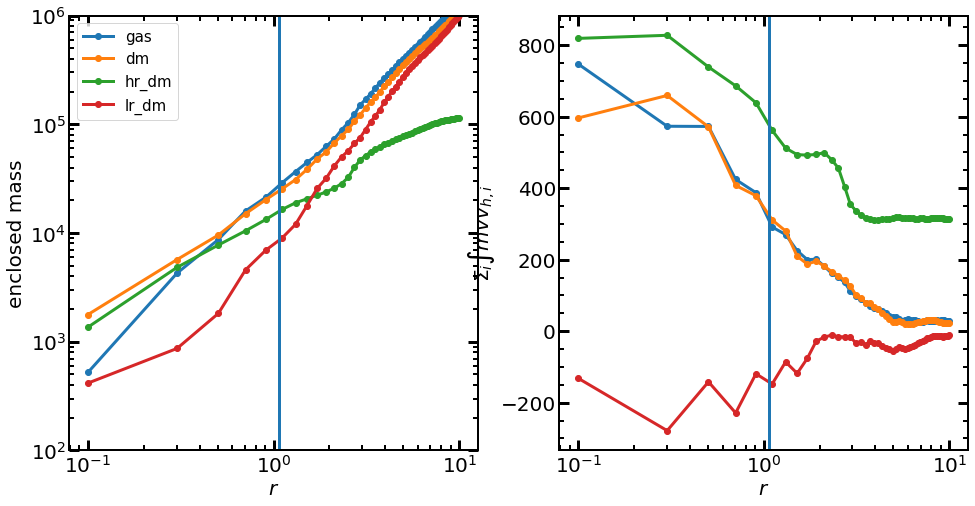

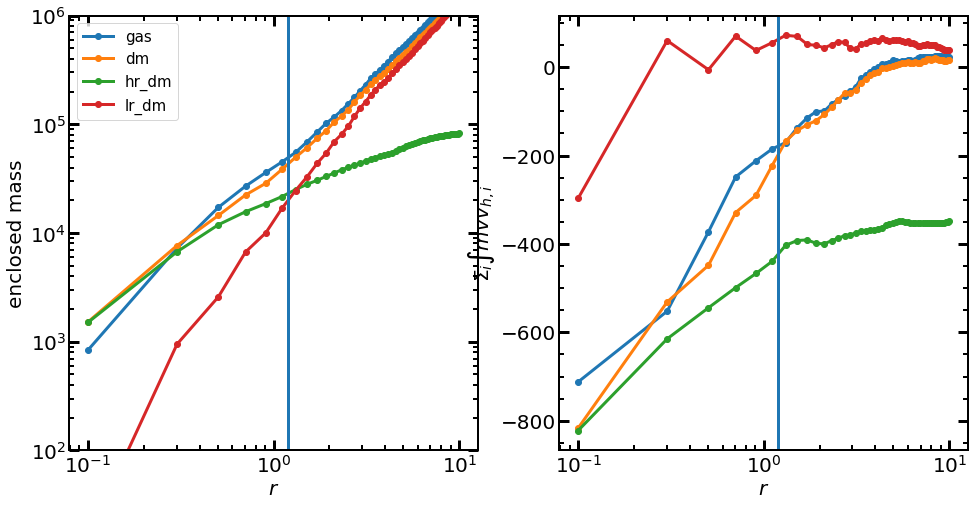

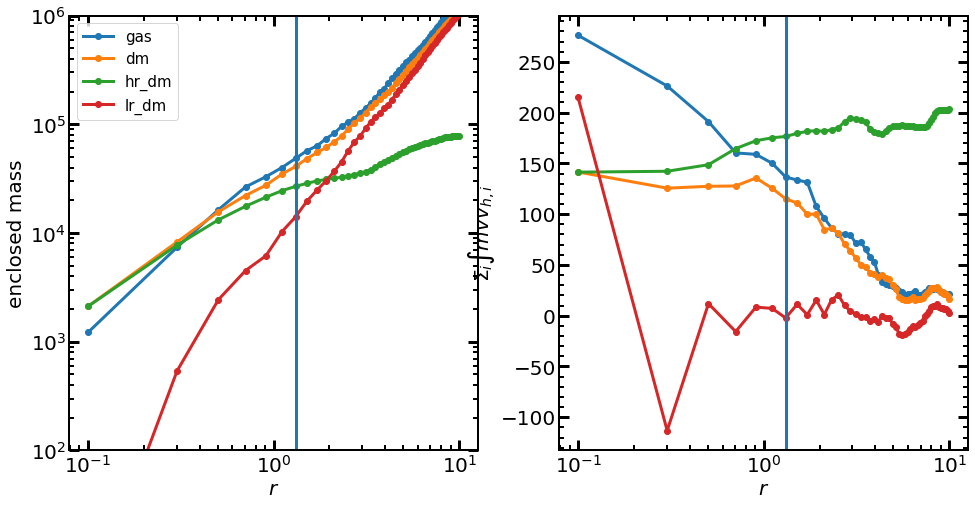

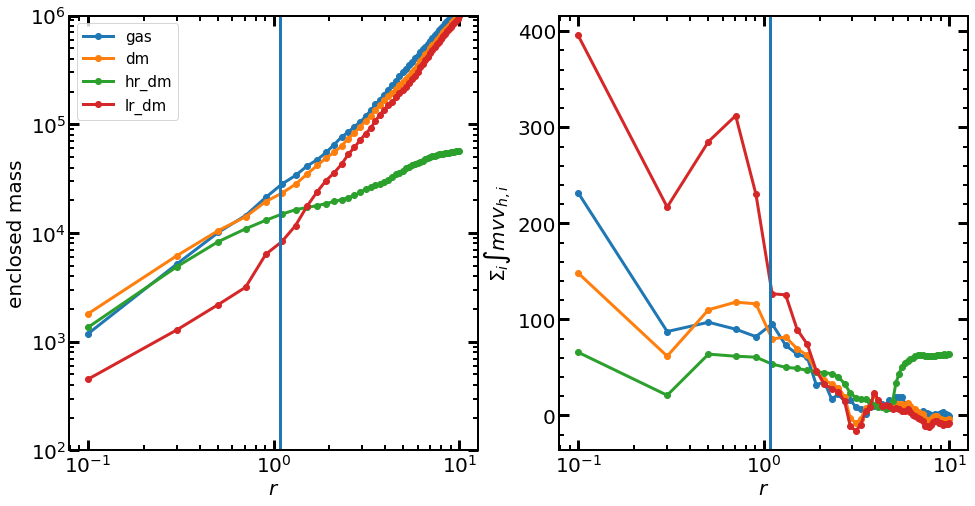

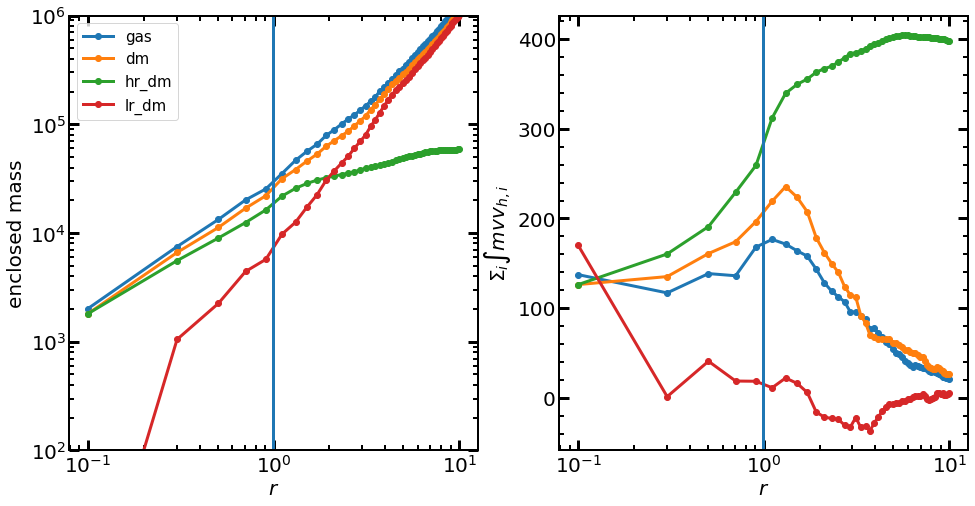

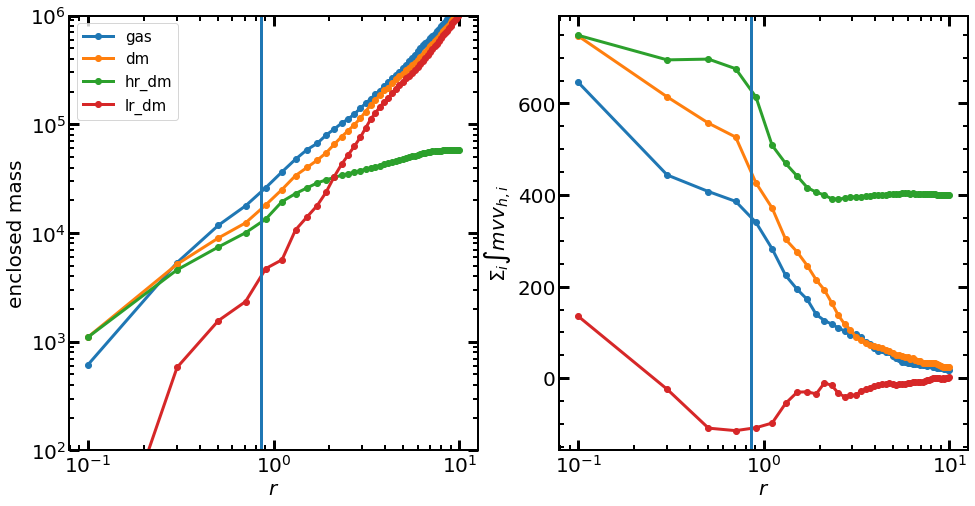

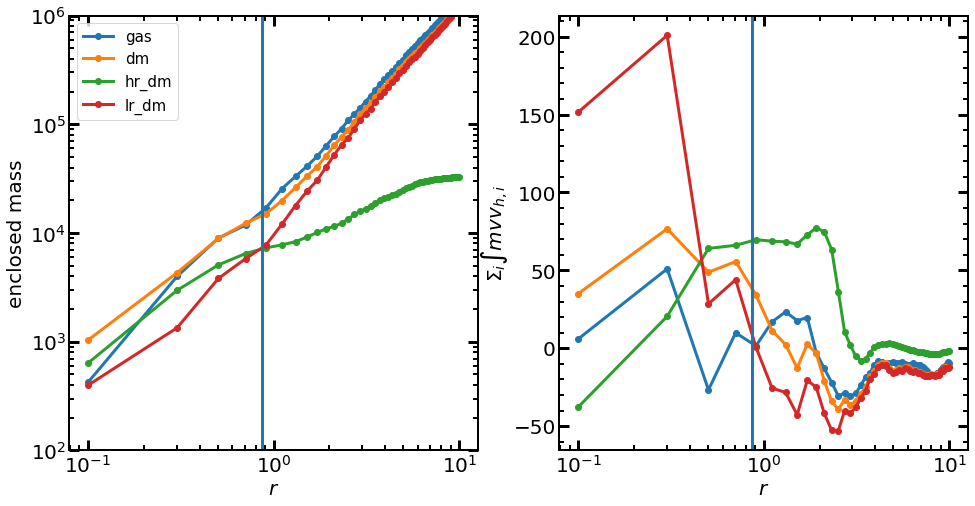

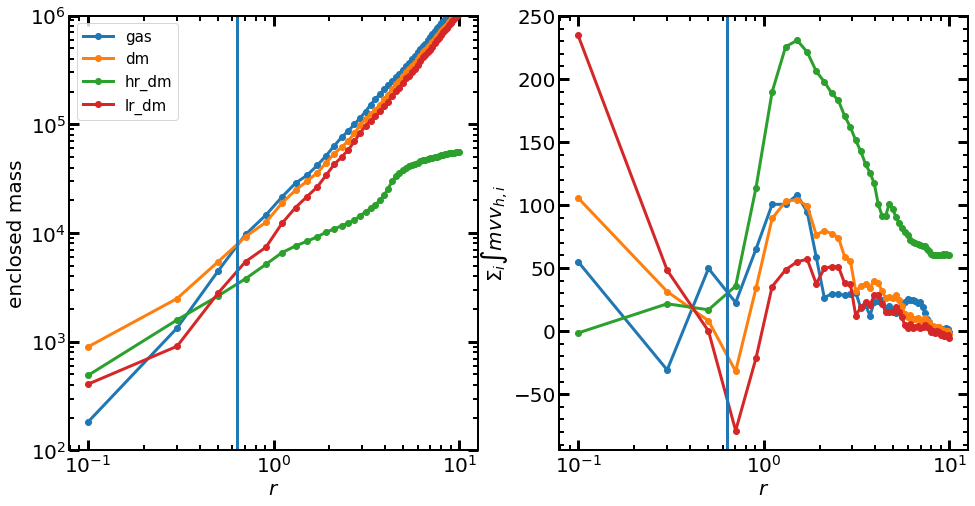

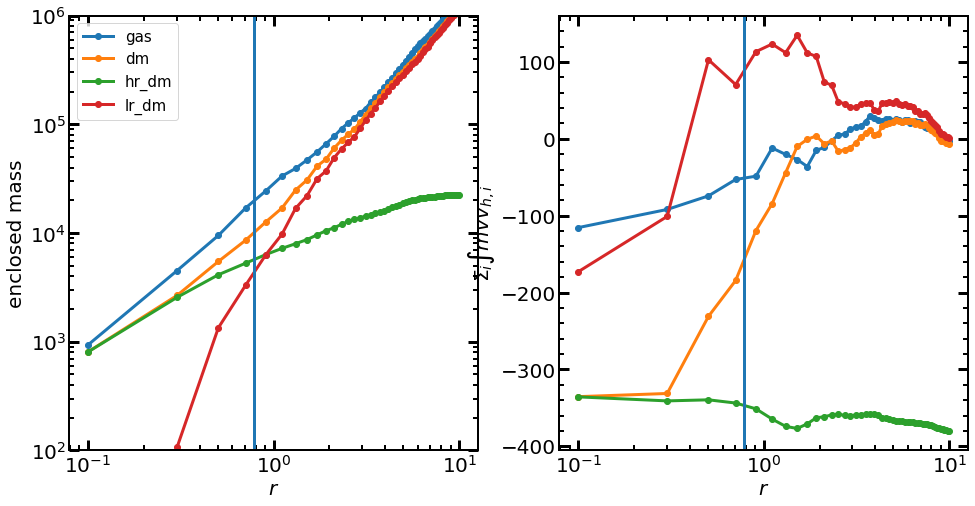

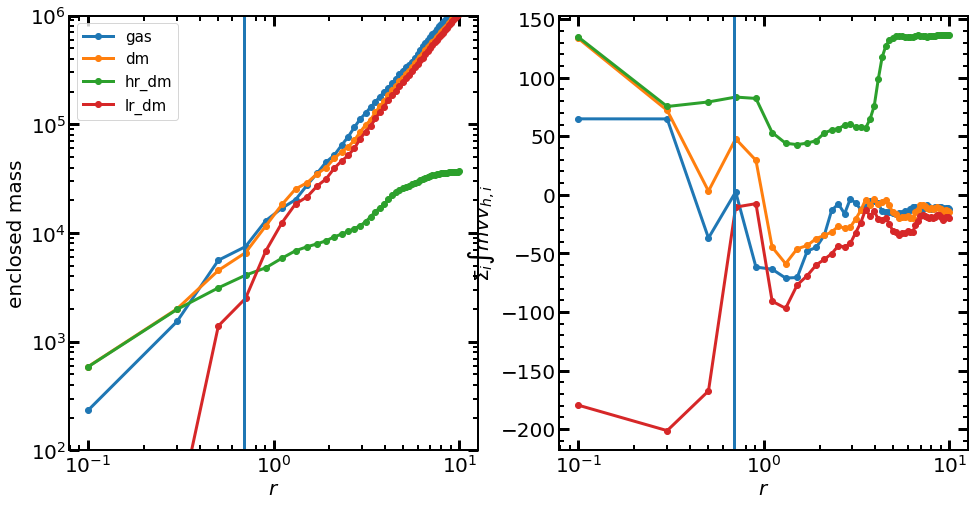

In [16]:
for ihalo in range(10):
    hv = hvel[mask][ihalo]/np.abs(hvel[mask][ihalo])
    fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(16,8))
    for key in ['gas','dm','hr_dm','lr_dm']:
        _fb = fb if key=='gas' else 1.
        ax[0].loglog(rp_bins, mass_per_halo[key][ihalo]/_fb,'-o',label=key)
        #ax[1].plot(rp_bins, tkSZ_per_halo[key][ihalo]/_fb * hv,'-o',label=key)
        ax[1].semilogx(rp_bins, tkSZ_per_halo[key][ihalo]/mass_per_halo[key][ihalo],'-o',label=key)
    
    
    ax[0].axvline(r200[mask][ihalo])
    ax[1].axvline(r200[mask][ihalo])
    ax[0].set_ylim(top=1e6,bottom=1e2)
    #ax[1].set_ylim(top=1e7, bottom=-1e7)
    ax[0].set_ylabel('enclosed mass')
    ax[1].set_ylabel(r'$\Sigma_i \int m v v_{h,i}$')
    ax[0].set_xlabel(r'$r$')
    ax[1].set_xlabel(r'$r$')
    ax[0].legend()
    #plt.ylim(top=1e6)

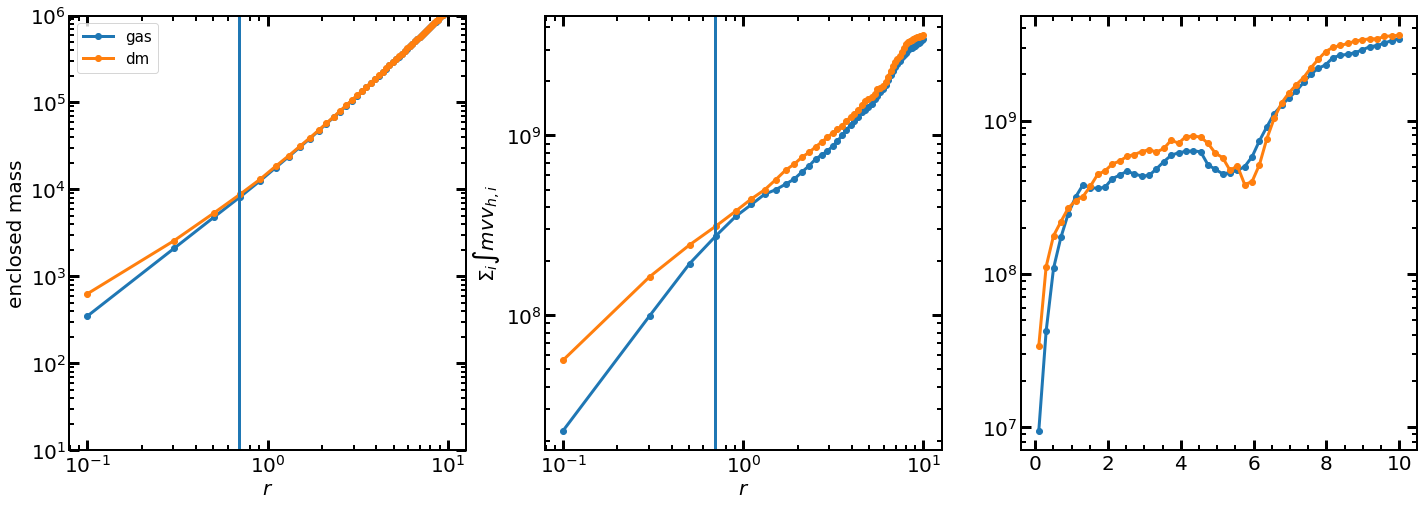

In [17]:
#hv = hvel[mask]/np.abs(hvel[mask]) # in reality without the division
hv = hvel[mask]

fig,ax=plt.subplots(ncols=3,nrows=1,figsize=(24,8))
for key in ['gas','dm']:#,'hr_dm','lr_dm']:
    _fg = fg if key=='gas' else 1. 
    
    _mass = np.nanmean(mass_per_halo[key]/_fg, axis=0)
    _tkSZ = np.nanmean(tkSZ_per_halo[key].T * hv ,axis=1) / _fg
    _tkSZ_back = bacco.utils.interpol(np.sqrt(2)*rp_bins,rp_bins,_tkSZ, logx=True,logy=True)
    _tkSZ_ap = (2*_tkSZ - _tkSZ_back) # Aperture filter
    
    ax[0].loglog(rp_bins, _mass, '-o',label=key)
    #ax[1].plot(rp_bins, tkSZ_per_halo[key][ihalo]/_fb * hv,'-o',label=key)
   # ax[1].semilogx(rp_bins, np.nanmean((tkSZ_per_halo[key]/mass_per_halo[key]).T * hv ,axis=1),'-o',label=key)
    ax[1].loglog(rp_bins, _tkSZ,'-o',label=key)
    ax[2].semilogy(rp_bins, _tkSZ_ap,'-o',label=key)
    
ax[0].axvline(r200[mask][ihalo])
ax[1].axvline(r200[mask][ihalo])
ax[0].set_ylim(top=1e6,bottom=1e1)
#ax[1].set_ylim(top=1e7, bottom=-1e7)
ax[0].set_ylabel('enclosed mass')
ax[1].set_ylabel(r'$\Sigma_i \int m v v_{h,i}$')
ax[0].set_xlabel(r'$r$')
ax[1].set_xlabel(r'$r$')
ax[0].legend()
#plt.ylim(top=1e6)

# 3d profiles

In [18]:
def compute_profile(r, mass, bins_r, space='log'):

    bins_r = np.array(bins_r)
    if space=='log':
        xx = 10**((np.log10(bins_r[1:])+np.log10(bins_r[:-1]))/2.)
    elif space=='lin':
        xx = 0.5*(bins_r[1:] + bins_r[:-1])
    volume = 4./3 * np.pi *  (bins_r[1:]**3-bins_r[:-1]**3)

    dig_r = np.digitize(r, bins_r, right=True)-1
    m = np.array([np.sum(mass[dig_r==i]) for i in range(len(bins_r)-1)])
    rho = m / volume

    return xx, m, rho

In [24]:
ih=3

In [25]:
_hpos = np.array([hpos[mask][ih]])
_r200 = np.array([r200[mask][ih]])

In [28]:
rbins = np.logspace(-2, 1, 20)
_pos = pos_gas
_mass = mass_gas

# Way 1 : using halotools
# If you pass many _hpos, it will return the mean density profile
y,c = ht.radial_profile_3d(_hpos, _pos, _mass, return_counts=True,rbins_absolute=rbins)
rr = 10**((np.log10(rbins[1:])+np.log10(rbins[:-1]))*0.5)
#rr = (rbins[1:]+rbins[:-1])*0.5
volume = 4 * np.pi / 3 *(rbins[1:]**3 - rbins[:-1]**3)

dens1 = y * c / volume
x1 = rr

# Way 2 : by - hand
for ih in range(1):
    drad = np.sqrt(np.sum((_pos-_hpos)**2,axis=1))
    x2, m, dens2 = compute_profile(drad, _mass, rbins)
    

Text(0.5, 0, '$r$')

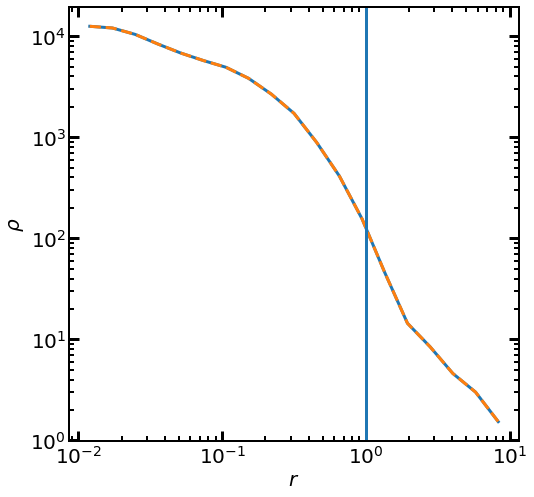

In [29]:
plt.figure(figsize=(8,8))
plt.loglog(x1, dens1)
plt.loglog(x2, dens2, ls='--')

plt.axvline(1.)
plt.ylabel(r'$\rho$')
plt.xlabel(r'$r$')